[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/sunilmogadati/systems-in-production/blob/main/implementation/notebooks/Linear_Regression.ipynb)

Playbook: [AI / Machine Learning](../../playbooks/ai/ml/README.md)

# Step 1: Linear Regression — Where ALL of ML Begins

**For:** AI (Artificial Intelligence) Engineer Accelerator — Cohort 01  
**Facilitator:** Sunil Mogadati

**What we'll cover today:**
- What Machine Learning actually IS (in one sentence)
- The simplest ML algorithm: Linear Regression
- How a machine "learns" from data
- How to measure whether the machine learned well or poorly
- The #1 mistake beginners make (data leakage) — and how to avoid it
- When Linear Regression works and when it fails

---

## The One-Sentence Definition of Machine Learning

> **Machine Learning = writing a program where YOU define the structure, and the DATA fills in the logic.**

In traditional programming, you write rules: `if income > 50K and credit > 700: approve_loan()`.
In ML, you give the computer examples of approved and rejected loans, and it FIGURES OUT the rules itself.

**Why is this powerful?** Because sometimes the rules are too complex for humans to write.
Can you write rules to recognize a cat in a photo? To predict which customers will cancel?
To translate English to Spanish? You can't — but ML can learn these from examples.

## Why Start with Linear Regression?

Every ML algorithm — from Random Forest to ChatGPT — does the same 3 things:

1. **Make a prediction** (guess an answer)
2. **Measure how wrong it was** (compare guess to reality)
3. **Adjust to be less wrong** (tweak the model)

Linear Regression is the **simplest** algorithm that shows all 3 steps clearly.
Master this, and everything else is just a more complex version of the same pattern.

## Glossary — Abbreviations Used in This Notebook

Keep this handy. Every abbreviation below is explained when first used, but this is your quick reference:

| Abbreviation | Full Form | Plain English |
|-------------|-----------|---------------|
| **ML** | Machine Learning | Teaching computers to learn from data instead of writing explicit rules |
| **DL** | Deep Learning | ML using neural networks with many layers |
| **MSE** | Mean Squared Error | Average of (squared mistakes) — how wrong the model is overall |
| **RMSE** | Root Mean Squared Error | Square root of MSE — puts the error back in the same units as your data |
| **MAE** | Mean Absolute Error | Average of the absolute mistakes — simpler and more intuitive than MSE |
| **R²** | R-squared (Coefficient of Determination) | How much better your model is than just guessing the average (0 to 1) |
| **LR** | Linear Regression | The algorithm that finds the best straight line through data |
| **NLP** | Natural Language Processing | Teaching computers to understand and generate human language |
| **RAG** | Retrieval-Augmented Generation | Connecting an LLM (Large Language Model) to your own documents |
| **OOP** | Object-Oriented Programming | Programming with classes and objects |
| **API** | Application Programming Interface | A way for programs to talk to each other |
| **EDA** | Exploratory Data Analysis | Looking at your data before building models — charts, stats, patterns |
| **SGD** | Stochastic Gradient Descent | The algorithm that nudges model parameters to reduce error |
| **std** | Standard Deviation | How spread out numbers are from the average |

#### Math Symbols Used in This Notebook

| Symbol | How to Read It | What It Means |
|--------|---------------|---------------|
| **ŷ** | "y-hat" | The model's predicted value |
| ***** | "times" | Multiplication: `w * sqft` = "w times square footage" |
| **²** | "squared" | Multiplied by itself: `(y - ŷ)²` = "y minus y-hat, squared" |
| **√** | "square root of" | `√MSE` = "square root of MSE" (gives RMSE) |
| **Σ** | "the sum of" | Add up all values: `Σ(y - ŷ)²` = "the sum of y minus y-hat squared" |
| **R²** | "R-squared" | Coefficient of determination — how much variance the model explains (0 to 1) |
| **≈** | "approximately" | Close but not exact: `R² ≈ 0.85` |
| **μ** | "mew" | Mean (average) of a dataset |
| **σ** | "sigma" | Standard deviation — how spread out the data is |
| **AI** | Artificial Intelligence |
| **GPT** | Generative Pre-trained Transformer |

## Part 1: The Concept (No Code Yet)

### What is Linear Regression in plain English?

Imagine you're a real estate agent. You've seen hundreds of houses sell.
You notice a pattern: **bigger houses cost more.** Not perfectly — a 2,000 sqft
house isn't always exactly double a 1,000 sqft house — but there's a clear trend.

Linear Regression is the computer doing what your brain does naturally:
**drawing the best straight line through the data** so it can predict new values.

- Input: house size (square feet)
- Output: predicted price
- Method: find the line that fits the data best

That's the entire algorithm.

### The Three Questions That Define ALL of ML

Every ML algorithm answers these same 3 questions. Only the answers change:

| Question | Plain English | ML Term | Linear Regression's Answer |
|----------|--------------|---------|---------------------------|
| What shape is my guess? | "I think the pattern is a straight line" | **Model** | `price = weight * size + bias` |
| How do I measure mistakes? | "How far off is my line from the actual data?" | **Loss Function** | Mean Squared Error (MSE) |
| How do I improve? | "Nudge the line until it fits better" | **Optimization** | Gradient Descent |

**Why this matters for later:** When we get to neural networks (Step 5+),
the answers change — the model becomes millions of parameters, the loss
function becomes cross-entropy — but **the 3 questions stay the same.**
If you understand these 3 here, you'll understand them everywhere.

## Architect's Decision Checklist — Before You Code

Before writing a single line of ML code, an experienced engineer asks these questions. This checklist applies to **every** ML project, not just linear regression.

| Decision | Question | Linear Regression's Answer |
|:---------|:---------|:--------------------------|
| **Problem Type** | Am I predicting a number or a category? | Number (regression) |
| **Data Shape** | How many features? How many samples? | 1-8 features, 5000 samples |
| **Baseline** | What's the simplest approach that could work? | Average of all prices |
| **Evaluation** | How will I know if the model is good enough? | RMSE < $30K, R² > 0.7 |
| **Splitting** | How do I prevent cheating (data leakage)? | 80/20 train/test split |
| **Scaling** | Are features on wildly different scales? | Yes → StandardScaler |
| **Interpretability** | Do stakeholders need to understand predictions? | Yes → coefficients explain each feature |

> **The pattern:** Every ML project starts with these 7 questions. Only the answers change as you move to more complex algorithms.


## Part 2: The Hello World (5 Lines)

Let's see the absolute minimum code that does ML.

In [1]:
# ============================================================
# THE SIMPLEST ML PROGRAM IN EXISTENCE — Just 5 lines of real code
# ============================================================

from sklearn.linear_model import LinearRegression
import numpy as np

# 
# Think of it like a spreadsheet:
#   Column X = house sizes (in square feet)
#   Column y = prices (in $1000s)
#
# NOTE: X must be 2D (rows * columns), even if there's only 1 column.
# That's why each value is wrapped in its own list: [[600], [800], ...]
# This is because real ML usually has MULTIPLE input columns.
X = np.array([[600], [800], [1000], [1200], [1400], [1600], [1800], [2000]])
y = np.array([150, 180, 210, 250, 280, 320, 350, 380])

model = LinearRegression()
model.fit(X, y)

prediction = model.predict([[1500]])
print(f"Predicted price for 1,500 sqft: ${prediction[0]:.0f}K")
print()
print("That's it. That's machine learning.")
print("We gave the computer data, it found a pattern, and now it can predict new values.")
print("Everything from here on is making this BETTER, FASTER, and MORE RELIABLE.")

Predicted price for 1,500 sqft: $299K

That's it. That's machine learning.
We gave the computer data, it found a pattern, and now it can predict new values.
Everything from here on is making this BETTER, FASTER, and MORE RELIABLE.


### What Just Happened? (Slower Than You Think)

`model.fit(X, y)` did three things:
1. Tried a line (`y = w*x + b` with some initial w and b)
2. Measured how far every data point was from that line (loss)
3. Adjusted w and b until the total distance was minimized

Let's see what it found:

In [2]:
# ============================================================
# ============================================================

#   model.coef_      = the SLOPE of the line (called "weight" or "coefficient")
#   model.intercept_ = the Y-INTERCEPT (called "bias")
#
# Together, they form the equation: price = weight * sqft + bias
# This is literally y = mx + b from high school math.
# The model figured out the best m and b by looking at the data.

w = model.coef_[0]      # The slope — how much price goes up per sqft
b = model.intercept_    # The starting point — price when sqft = 0 (theoretical)

print(f"The learned equation: price = {w:.4f} * sqft + {b:.2f}")
print(f"")
print(f"IN PLAIN ENGLISH:")
print(f"  Every additional square foot adds about ${w*1000:.0f} to the price.")
print(f"  The base price (intercept) is ${b:.0f}K — this is theoretical since")
print(f"  a 0 sqft house doesn't exist, but the math needs a starting point.")
print(f"")
print(f"LET'S VERIFY BY HAND:")
print(f"  For 1,500 sqft: {w:.4f} * 1500 + {b:.2f} = {w * 1500 + b:.2f}")
print(f"  That matches our prediction above! The model is just plugging into this equation.")
print(f"")
print(f"THINK OF IT THIS WAY:")
print(f"  .fit() is like COMPILING — it takes raw data and produces an optimized program.")
print(f"  The 'program' is just two numbers: w={w:.4f} and b={b:.2f}.")
print(f"  .predict() is like RUNNING that program on new input.")
print(f"  The entire 'intelligence' of this model lives in those two numbers.")

SyntaxError: invalid syntax (<ipython-input-2-58b353809952>, line 16)

## Part 3: See It — The Line Through The Data

In [3]:
# ============================================================
# VISUALIZE IT — See the line through the data
# ============================================================
# A picture is worth a thousand words in ML (Machine Learning). Let's SEE what the model did.
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# BLUE DOTS = our actual data points (the houses we know about)
plt.scatter(X, y, color='blue', s=100, zorder=5, label='Actual data (what we KNOW)')

# RED LINE = the line the model learned
# We generate 100 points along the x-axis and predict y for each one.
# This draws a smooth line showing the model's "understanding" of the pattern.
X_line = np.linspace(400, 2200, 100).reshape(-1, 1)
y_line = model.predict(X_line)
plt.plot(X_line, y_line, color='red', linewidth=2, 
         label=f'Learned line: price = {w:.2f} * sqft + {b:.1f}')

# GREEN STAR = our prediction for a house the model has NEVER seen
# This is the whole point — we can now estimate prices for new houses.
plt.scatter([1500], prediction, color='green', s=200, marker='*', zorder=5, 
            label=f'NEW prediction: 1500 sqft → ${prediction[0]:.0f}K')

# GRAY DASHED LINES = residuals (the "errors" for each data point)
# These show how far each actual data point is from the line.
# The model's job is to make these gray lines as SHORT as possible.
# Shorter residuals = better fit = the line is closer to the real data.
y_pred_train = model.predict(X)
for i in range(len(X)):
    plt.plot([X[i][0], X[i][0]], [y[i], y_pred_train[i]], 
             color='gray', linestyle='--', alpha=0.5)

plt.xlabel('House Size (sq ft)', fontsize=12)
plt.ylabel('Price ($1000s)', fontsize=12)
plt.title('Linear Regression: Finding the Best Line Through Data', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("WHAT YOU'RE LOOKING AT:")
print("  Blue dots  = real data (houses that actually sold)")
print("  Red line   = the model's 'understanding' of the pattern")
print("  Green star = prediction for a NEW house (1,500 sqft)")
print("  Gray lines = RESIDUALS — the error for each data point")
print()
print("The model's ENTIRE JOB was to position the red line so that")
print("the gray lines (errors) are as small as possible overall.")
print("That's what .fit() did behind the scenes.")

SyntaxError: invalid syntax (<ipython-input-3-008186eb6117>, line 18)

## Part 4: The Loss Function — How "Wrong" Is Measured

This is the single most important concept in all of ML. Every algorithm —
from Linear Regression to GPT (Generative Pre-trained Transformer) — has a loss function. It answers:
**"How far off are my predictions from reality?"**

### Mean Squared Error (MSE) — In Plain English

1. For each data point: `error = actual - predicted`
2. Square each error (so negatives don't cancel positives)
3. Average all squared errors

**Why squared?** Two reasons:
- A prediction off by 20 is MORE than twice as bad as one off by 10 (squared penalizes big errors)
- It makes the math smooth for optimization (the curve has a clean minimum)

In [4]:
# ============================================================
# ============================================================
#
# The loss function answers: "How wrong is this model, overall?"
# For Linear Regression, the loss function is MSE (Mean Squared Error).

predictions = model.predict(X)

print("STEP-BY-STEP: How wrong is the model for each house?")
print()
print(f"{'House Size':>10} {'Actual $K':>10} {'Predicted $K':>12} {'Error':>8} {'Error²':>10}")
print("-" * 55)

squared_errors = []
for i in range(len(X)):
    # Error = what actually happened MINUS what the model predicted
    # Positive error = model predicted too LOW (underestimate)
    # Negative error = model predicted too HIGH (overestimate)
    error = y[i] - predictions[i]
    
    # WHY DO WE SQUARE THE ERROR?
    # 1. Some errors are positive, some negative — they'd cancel out if we just averaged.
    #    Squaring makes them all positive.
    # 2. Squaring PUNISHES big errors more. An error of 20 becomes 400 (not just 20).
    #    This forces the model to avoid large mistakes, even if it means small ones elsewhere.
    sq_error = error ** 2
    squared_errors.append(sq_error)
    print(f"{X[i][0]:>10.0f} {y[i]:>10.0f} {predictions[i]:>12.2f} {error:>8.2f} {sq_error:>10.2f}")

# MSE = the AVERAGE of all squared errors
# This is the single number that summarizes "how wrong is the model overall"
mse = np.mean(squared_errors)

# RMSE = square root of MSE
# Why? Because MSE is in "squared dollars" which makes no intuitive sense.
# Taking the square root puts it back into regular dollars.
rmse = np.sqrt(mse)

print(f"\n{'='*55}")
print(f"MSE  (Mean Squared Error):  {mse:.2f}")
print(f"RMSE (Root Mean Sq Error):  {rmse:.2f}")
print(f"")
print(f"WHAT DOES THIS MEAN IN ENGLISH?")
print(f"  On average, our predictions are off by about ${rmse:.0f}K.")
print(f"  For houses worth $150K-$380K, being off by ${rmse:.0f}K is pretty good!")
print(f"")
print(f"ANALOGY: Think of MSE like a test score for the model.")
print(f"  Each house is a test question.")
print(f"  The error is how wrong the model got that question.")
print(f"  MSE is the average 'wrongness' across all questions.")
print(f"  .fit() adjusted the model to get the LOWEST possible MSE.")

STEP-BY-STEP: How wrong is the model for each house?

House Size  Actual $K Predicted $K    Error     Error²
-------------------------------------------------------
       600        150       147.50     2.50       6.25
       800        180       181.07    -1.07       1.15
      1000        210       214.64    -4.64      21.56
      1200        250       248.21     1.79       3.19
      1400        280       281.79    -1.79       3.19
      1600        320       315.36     4.64      21.56
      1800        350       348.93     1.07       1.15
      2000        380       382.50    -2.50       6.25

MSE  (Mean Squared Error):  8.04
RMSE (Root Mean Sq Error):  2.83

WHAT DOES THIS MEAN IN ENGLISH?
  On average, our predictions are off by about $3K.
  For houses worth $150K-$380K, being off by $3K is pretty good!

ANALOGY: Think of MSE like a test score for the model.
  Each house is a test question.
  The error is how wrong the model got that question.
  MSE is the average 'wrongness' ac

## Part 5: R² Score — The Metric That Actually Tells You Something

MSE alone is hard to interpret. Is 42.5 good? Bad? Depends on the scale of your data.

**R² (R-squared)** answers a better question:
**"How much better is my model than just guessing the average every time?"**

- R² = 1.0 → perfect predictions
- R² = 0.0 → no better than guessing the average
- R² < 0.0 → worse than guessing the average (your model is actively harmful)

In [5]:
# ============================================================
# R² SCORE — A metric that actually makes sense
# ============================================================
# MSE (Mean Squared Error) alone is hard to interpret. Is 8.04 good? Bad? 
# It depends on the scale — $8K error on a $5M house is great;
# $8K error on a $10K car is terrible.
#
# R² (R-squared) solves this by answering a RELATIVE question:
# "How much better is my model than the DUMBEST possible model?"
#
# The dumbest model: just predict the AVERAGE every time.
# If houses average $277K, predict $277K for every house.
# R² tells you how much better YOUR model is than that.

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Compute R² — scikit-learn does this in one line
r2 = r2_score(y, predictions)

# MAE (Mean Absolute Error) — simpler than MSE
# Just the average of |error| — no squaring. More intuitive.
mae = mean_absolute_error(y, predictions)

print(f"R² Score: {r2:.4f}")
print(f"")
print(f"WHAT DOES R² = {r2:.4f} MEAN?")
print(f"  Our model explains {r2*100:.1f}% of the variation in house prices.")
print(f"  Only {(1-r2)*100:.1f}% is left unexplained.")
print(f"  (The unexplained part = stuff we didn't give the model,")
print(f"   like location, condition, school district, etc.)")
print(f"")
print(f"R² CHEAT SHEET:")
print(f"  R² = 1.0  → Perfect. Model predicts exactly right every time.")
print(f"  R² = 0.8  → Great. Model captures most of the pattern.")
print(f"  R² = 0.5  → OK. Model is better than guessing, but misses a lot.")
print(f"  R² = 0.0  → Useless. No better than just guessing the average.")
print(f"  R² < 0.0  → HARMFUL. Worse than guessing the average!")
print(f"")
print(f"MAE (Mean Absolute Error): ${mae:.2f}K")
print(f"  This is simpler than RMSE (Root Mean Squared Error — same units as your data) — just the average error, no squaring.")
print(f"  On average, our prediction is off by ${mae:.0f}K.")
print(f"")
print(f"┌────────────────────────────────────────────────────┐")
print(f"│ WHEN TO USE WHICH METRIC:                          │")
print(f"│                                                    │")
print(f"│ R²   → Comparing models ('which is better?')      │")
print(f"│ RMSE → When big errors are really bad              │")
print(f"│ MAE  → When you want intuitive 'average error'     │")
print(f"│ MSE  → Used internally by training algorithms      │")
print(f"└────────────────────────────────────────────────────┘")

R² Score: 0.9986

WHAT DOES R² = 0.9986 MEAN?
  Our model explains 99.9% of the variation in house prices.
  Only 0.1% is left unexplained.
  (The unexplained part = stuff we didn't give the model,
   like location, condition, school district, etc.)

R² CHEAT SHEET:
  R² = 1.0  → Perfect. Model predicts exactly right every time.
  R² = 0.8  → Great. Model captures most of the pattern.
  R² = 0.5  → OK. Model is better than guessing, but misses a lot.
  R² = 0.0  → Useless. No better than just guessing the average.
  R² < 0.0  → HARMFUL. Worse than guessing the average!

MAE (Mean Absolute Error): $2.50K
  This is simpler than RMSE — just the average error, no squaring.
  On average, our prediction is off by $2K.

┌────────────────────────────────────────────────────┐
│ WHEN TO USE WHICH METRIC:                          │
│                                                    │
│ R²   → Comparing models ('which is better?')      │
│ RMSE → When big errors are really bad              │
│ M

## Part 6: Train/Test Split — Why You MUST Do This

Right now we have a fatal flaw: **we tested the model on the same data we trained it on.**

That's like a teacher giving a student the exact exam questions as homework,
then being surprised they aced the exam. You're measuring **memorization**, not
**understanding**.

### The Rule

- **Training data:** what the model learns from (the homework)
- **Test data:** what you evaluate on (the exam) — the model has NEVER seen this

**Software analogy:** It's like running your test suite against the same
hard-coded fixture data that your code was written to handle. Of COURSE it passes.
Real testing means unseen inputs.

In [6]:
# ============================================================
# TRAIN/TEST SPLIT — The Most Important Discipline in ML
# ============================================================
# 
# PROBLEM: Above, we tested the model on the SAME data we trained it on.
# That's like giving a student the exact exam questions as homework —
# of COURSE they ace the exam. But did they actually LEARN?
#
# SOLUTION: Split the data into TWO groups:
#   Training set (80%): The model learns from this.
#   Test set (20%):     We evaluate on this. The model has NEVER seen it.
#
# This is the most fundamental rule in ML:
# NEVER evaluate on data the model was trained on.
# ============================================================

from sklearn.model_selection import train_test_split
from sklearn.datasets import make_regression

np.random.seed(42)  # Makes results reproducible — same "random" data every time
n_samples = 5000    # 5,000 houses

# Create 8 features that mimic real housing data
# Each feature is something you'd find on a real estate listing
MedInc = np.random.exponential(3.5, n_samples) + 0.5      # Median income in the area
HouseAge = np.random.uniform(1, 52, n_samples)             # How old the house is
AveRooms = np.random.normal(5.5, 1.5, n_samples).clip(1)  # Average rooms per house
AveBedrms = np.random.normal(1.1, 0.3, n_samples).clip(0.5)  # Average bedrooms
Population = np.random.exponential(1400, n_samples) + 3    # People in the neighborhood
AveOccup = np.random.normal(3.1, 0.8, n_samples).clip(1)  # Average people per household
Latitude = np.random.uniform(32.5, 41.9, n_samples)        # North-south location
Longitude = np.random.uniform(-124.3, -114.3, n_samples)   # East-west location

# The house price is influenced by these features (with some random noise)
# This formula is the "truth" that the model will try to discover
y_full = (
    0.42 * MedInc          # Higher income area → higher prices (strong effect)
    - 0.005 * HouseAge     # Older houses → slightly lower prices
    + 0.12 * AveRooms      # More rooms → higher prices
    - 0.08 * AveBedrms     # More bedrooms (controlling for rooms) → lower prices
    - 0.00003 * Population # Crowded areas → slightly lower prices
    - 0.04 * AveOccup      # More people per house → lower prices
    - 0.02 * Latitude      # Location effect
    - 0.01 * Longitude     # Location effect
    + np.random.normal(0, 0.4, n_samples)  # Random noise — real data is never perfect
    + 2.5  # Base price
)
y_full = y_full.clip(0.15, 5.0)  # Cap prices to realistic range (in $100K)

X_full = np.column_stack([MedInc, HouseAge, AveRooms, AveBedrms, 
                           Population, AveOccup, Latitude, Longitude])

class DataHolder:
    feature_names = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 
                     'Population', 'AveOccup', 'Latitude', 'Longitude']
data = DataHolder()

print(f"Dataset: {X_full.shape[0]} houses, {X_full.shape[1]} features")
print(f"Features: {data.feature_names}")
print(f"Target: median house value (in $100Ks)")
print(f"")

# ============================================================
# THE SPLIT — This is where the discipline happens
# ============================================================
# train_test_split randomly divides data into two groups.
# test_size=0.2 means 20% goes to test, 80% to training.
# random_state=42 makes the split reproducible (same split every time).
X_train, X_test, y_train, y_test = train_test_split(
    X_full, y_full, test_size=0.2, random_state=42
)

print(f"Training set: {X_train.shape[0]} houses (the model learns from ONLY these)")
print(f"Test set:     {X_test.shape[0]} houses (the model has NEVER seen these)")
print(f"")
print(f"RULE: From this point forward, the test set is LOCKED AWAY.")
print(f"We only look at it ONCE — at the very end — to get our final score.")
print(f"If we peek at the test set during training, we're cheating.")

Dataset: 5000 houses, 8 features
Features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
Target: median house value (in $100Ks)

Training set: 4000 houses (the model learns from ONLY these)
Test set:     1000 houses (the model has NEVER seen these)

RULE: From this point forward, the test set is LOCKED AWAY.
We only look at it ONCE — at the very end — to get our final score.
If we peek at the test set during training, we're cheating.


## WAIT — What exactly ARE X_train and y_train?

This is a **critical** concept that trips up beginners.

When you see `model.fit(X_train, y_train)`, it looks like two variables — like `x` and `y` from high school algebra. **That's misleading.**

- **`X_train` is NOT a single number.** It's an entire **spreadsheet** — a table with 4,000 rows and 8 columns. Each row is one house. Each column is one feature (income, age, rooms, etc.). All 8 features are in there, intact, nothing collapsed.
- **`y_train` is a single column** — the 4,000 prices (the correct answers the model learns from).

So `model.fit(X_train, y_train)` means: *"Here are 4,000 houses described by 8 attributes each, and here's the price for each one. Figure out the relationship."*

### The model is NOT a 2D line

With 8 features, the model creates a **hyperplane** in 9-dimensional space (8 inputs + 1 output). The equation under the hood is:

```
price = w1*MedInc + w2*HouseAge + w3*AveRooms + w4*AveBedrms 
      + w5*Population + w6*AveOccup + w7*Latitude + w8*Longitude + bias
```

That's 8 dimensions of input — you can't draw that on paper.

**So why do we draw 2D plots?** Because human eyes only work in 2D/3D. When we plot `predicted vs actual` prices, we're projecting the model's RESULTS down to 2D so we can eyeball quality. The model itself lives in 9D.

**Analogy:** You build a distributed system with 8 microservices. You can't visualize the whole thing at once, so you look at a dashboard showing "requests in vs responses out." That dashboard is 2D. Your system isn't.

The code cell below proves this — run it and see the actual shapes.

In [ ]:
# ============================================================
# PROOF: X_train is a TABLE, not a single number
# ============================================================
# Let's look at what X_train and y_train ACTUALLY are.

print("=" * 60)
print("WHAT X_train AND y_train ACTUALLY LOOK LIKE")
print("=" * 60)
print()

# .shape tells you (rows, columns) — like a spreadsheet's dimensions
print(f"X_train shape: {X_train.shape}")
print(f"  → That means {X_train.shape[0]} rows (houses) and {X_train.shape[1]} columns (features)")
print(f"  → ALL 8 features are in here. Nothing was collapsed.")
print()
print(f"y_train shape: {y_train.shape}")
print(f"  → That's just {y_train.shape[0]} numbers — one price per house")
print()

# Show the first 3 rows so you can SEE it's a spreadsheet
print("First 3 rows of X_train (each row = one house, each column = one feature):")
print(f"{'':>4} {'MedInc':>8} {'HouseAge':>10} {'AveRooms':>10} {'AveBedrms':>10} {'Population':>12} {'AveOccup':>10} {'Latitude':>10} {'Longitude':>10}")
print("-" * 95)
for i in range(3):
    row = X_train[i]
    print(f"[{i}] {row[0]:>8.2f} {row[1]:>10.1f} {row[2]:>10.2f} {row[3]:>10.2f} {row[4]:>12.1f} {row[5]:>10.2f} {row[6]:>10.2f} {row[7]:>10.2f}")
print()
print(f"And their prices (y_train): {y_train[0]:.2f}, {y_train[1]:.2f}, {y_train[2]:.2f}  (in $100Ks)")
print()
print("KEY TAKEAWAY:")
print("  X (capital) = a TABLE of inputs (multiple features, multiple rows)")
print("  y (lowercase) = a COLUMN of answers (one number per row)")
print("  The model sees ALL 8 features. The 2D plots are just for human eyes.")


## How Does the "Graph" Change as You Add Features?

This is the key mental model to build. When you had **1 feature** (house size vs price),
you could draw a line on paper. Easy. But what happens with 2 features? 3? 8?

The answer: **each feature adds one dimension to the space.** The model is always a "flat surface" — it just exists in a space you can't draw anymore.

Run the cell below to see the progression.

In [4]:
# ============================================================
# VISUALIZING DIMENSIONS: From a Line to a Hyperplane
# ============================================================
# This is the single most important diagram in this notebook.
# It answers: "What does the model LOOK like with 8 features?"
#
# Short answer: You can't see it. But here's the progression.

from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(18, 13))
fig.suptitle('How Linear Regression "Looks" as You Add Features',
             fontsize=16, fontweight='bold', y=0.98)

# ---- PANEL 1: 1 feature = a LINE in 2D ----
# You know this from school: y = mx + b
# One input axis (size), one output axis (price). That's 2D.
ax1 = fig.add_subplot(2, 2, 1)
np.random.seed(42)
size = np.random.uniform(500, 3500, 80)
price_1d = 0.1 * size + 50 + np.random.normal(0, 40, 80)
ax1.scatter(size, price_1d, alpha=0.5, s=30, color='steelblue', label='Houses')
m, b = np.polyfit(size, price_1d, 1)  # Find best-fit line
x_line = np.linspace(400, 3600, 100)
ax1.plot(x_line, m * x_line + b, 'r-', linewidth=3, label='Model: a LINE')
ax1.set_xlabel('House Size (sq ft)', fontsize=11)
ax1.set_ylabel('Price ($K)', fontsize=11)
ax1.set_title('1 Feature = Model is a LINE\nprice = w1 x size + bias', fontsize=12, fontweight='bold')
ax1.legend(fontsize=10)
ax1.text(0.05, 0.95, '2D space\n(you can see this)', transform=ax1.transAxes,
         fontsize=10, va='top', bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.8))

# ---- PANEL 2: 2 features = a FLAT PLANE in 3D ----
# Now we have TWO input axes (size + age) and one output (price). That's 3D.
# The model is no longer a line — it's a flat tilted sheet.
# Think of it like a stiff piece of cardboard tilted in a room.
ax2 = fig.add_subplot(2, 2, 2, projection='3d')
size_2d = np.random.uniform(500, 3500, 100)
age_2d = np.random.uniform(1, 50, 100)
price_2d = 0.08 * size_2d - 1.5 * age_2d + 100 + np.random.normal(0, 30, 100)
ax2.scatter(size_2d, age_2d, price_2d, alpha=0.5, s=30, color='steelblue')
# Fit a flat plane through the points
A = np.column_stack([size_2d, age_2d, np.ones(100)])
coeffs = np.linalg.lstsq(A, price_2d, rcond=None)[0]
xx, yy = np.meshgrid(np.linspace(400, 3600, 20), np.linspace(0, 52, 20))
zz = coeffs[0] * xx + coeffs[1] * yy + coeffs[2]
ax2.plot_surface(xx, yy, zz, alpha=0.3, color='red')
ax2.set_xlabel('Size (sq ft)', fontsize=9)
ax2.set_ylabel('Age (yrs)', fontsize=9)
ax2.set_zlabel('Price ($K)', fontsize=9)
ax2.set_title('2 Features = Model is a FLAT PLANE\nprice = w1 x size + w2 x age + bias', fontsize=12, fontweight='bold')
ax2.text2D(0.02, 0.95, '3D space\n(last one you can see)', transform=ax2.transAxes,
           fontsize=10, bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.8))
ax2.view_init(elev=20, azim=135)

# ---- PANEL 3: The pattern ----
# This panel just spells out the rule:
# N features means the model is a flat surface in (N+1)-dimensional space.
ax3 = fig.add_subplot(2, 2, 3)
ax3.set_xlim(0, 10)
ax3.set_ylim(0, 10)
ax3.set_xticks([])
ax3.set_yticks([])
steps = [
    (1.5, 7.5, '1 feature', 'LINE in 2D', 'lightgreen', 'Can draw'),
    (1.5, 5.5, '2 features', 'PLANE in 3D', 'lightgreen', 'Can draw'),
    (1.5, 3.5, '3 features', 'FLAT SHEET in 4D', 'khaki', 'Cannot fully draw'),
    (1.5, 1.5, '8 features', 'HYPERPLANE in 9D', 'lightsalmon', 'Cannot draw at all'),
]
for x, y, label, desc, color, viz in steps:
    ax3.add_patch(plt.Rectangle((x-0.3, y-0.6), 8, 1.1,
                  facecolor=color, edgecolor='gray', linewidth=1.5, alpha=0.7))
    ax3.text(x, y+0.1, f'{label}  -->  {desc}', fontsize=12, fontweight='bold', va='center')
    ax3.text(x, y-0.3, viz, fontsize=10, va='center')
ax3.set_title('The Pattern: Each Feature Adds a Dimension', fontsize=12, fontweight='bold')
ax3.text(5, 9.3, 'The MODEL is always a flat surface.\nIt just lives in more dimensions than you can see.',
         fontsize=11, ha='center', style='italic',
         bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9))

# ---- PANEL 4: What we actually plot for 8 features ----
# Since we can't visualize 9D, we plot a "report card":
# predicted price vs actual price. If the dots land on the
# diagonal line, the model predicted correctly.
ax4 = fig.add_subplot(2, 2, 4)
actual = np.random.uniform(0.5, 5, 200)
predicted = actual + np.random.normal(0, 0.4, 200)
predicted = np.clip(predicted, 0.15, 5.5)
ax4.scatter(actual, predicted, alpha=0.4, s=25, color='steelblue', label='Each house')
ax4.plot([0, 6], [0, 6], 'r--', linewidth=2, label='Perfect prediction')
ax4.set_xlabel('Actual Price ($100K)', fontsize=11)
ax4.set_ylabel('Predicted Price ($100K)', fontsize=11)
ax4.set_title('8 Features: We Plot RESULTS, Not the Model\nPredicted vs Actual (a 2D report card)', fontsize=12, fontweight='bold')
ax4.legend(fontsize=10)
ax4.text(0.05, 0.95, 'This is NOT the model.\nThis is a report card\nshowing how well it did.',
         transform=ax4.transAxes, fontsize=10, va='top',
         bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9))
ax4.set_xlim(0, 5.5)
ax4.set_ylim(0, 5.5)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

print()
print('SUMMARY:')
print('  1 feature  -->  model is a LINE        (you draw it on paper)')
print('  2 features -->  model is a PLANE       (you can still see it in 3D)')
print('  3 features -->  model is a flat SHEET   (4D space — cannot fully draw)')
print('  8 features -->  model is a HYPERPLANE   (9D space — cannot draw at all)')
print()
print('The math is IDENTICAL at every step. The only thing that changes')
print('is how many w (weight) terms are in the equation.')
print()
print('  1 feature:  price = w1 x size + bias')
print('  2 features: price = w1 x size + w2 x age + bias')
print('  8 features: price = w1 x feat1 + w2 x feat2 + ... + w8 x feat8 + bias')
print()
print('Same recipe. More ingredients. That is it.')


SyntaxError: invalid syntax (<ipython-input-4-d8b632fcdeb2>, line 73)

In [7]:
# ============================================================
# ============================================================

model_real = LinearRegression()
model_real.fit(X_train, y_train)  # learns from 4,000 houses

y_pred_train = model_real.predict(X_train)  # predictions on data it SAW
y_pred_test = model_real.predict(X_test)    # predictions on data it NEVER SAW

r2_train = r2_score(y_train, y_pred_train)
r2_test = r2_score(y_test, y_pred_test)
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))

# The KEY comparison: how does performance on training data vs test data differ?
print(f"{'':>15} {'Train':>10} {'Test':>10} {'Gap':>10}")
print(f"{'-'*50}")
print(f"{'R² (R-squared) Score':>15} {r2_train:>10.4f} {r2_test:>10.4f} {abs(r2_train-r2_test):>10.4f}")
print(f"{'RMSE (Root Mean Squared Error — same units as your data) ($100K)':>15} {rmse_train:>10.4f} {rmse_test:>10.4f} {abs(rmse_train-rmse_test):>10.4f}")
print(f"")

# ============================================================
# HOW TO READ THIS TABLE — The Gap tells the story
# ============================================================
# Small gap (like here): The model performs similarly on seen and unseen data.
#   This means it learned real PATTERNS, not memorized specific data points.
#   This is called GENERALIZATION — and it's what we want.
#
# Large gap (train >> test): The model performs great on training data but
#   poorly on new data. This is called OVERFITTING — the model memorized
#   the training data instead of learning the underlying pattern.
#   It's like a student who memorized all the homework answers but can't
#   solve a new problem on the exam.

if abs(r2_train - r2_test) < 0.05:
    print("✅ Train and Test scores are close → model GENERALIZES well.")
    print("   It learned real patterns, not memorized specific houses.")
else:
    print("⚠️  Big gap between Train and Test → possible OVERFITTING.")
    print("   The model memorized training data instead of learning patterns.")

print(f"")
print(f"IMPORTANT: R² of {r2_test:.2f} means our model only explains")
print(f"{r2_test*100:.0f}% of price variation. That's because house prices")
print(f"depend on non-linear relationships that a straight line can't capture.")
print(f"This is the motivation for more powerful models later in this course.")

                     Train       Test        Gap
--------------------------------------------------
       R² Score     0.4787     0.4792     0.0004
   RMSE ($100K)     0.4648     0.4764     0.0116

✅ Train and Test scores are close → model GENERALIZES well.
   It learned real patterns, not memorized specific houses.

IMPORTANT: R² of 0.48 means our model only explains
48% of price variation. That's because house prices
depend on non-linear relationships that a straight line can't capture.
This is the motivation for more powerful models later in this course.


## Part 7: Feature Importance — Which Inputs Actually Matter?

In Linear Regression, the coefficients (weights) tell you exactly how much each
feature influences the prediction. This is one of LR's superpowers: **interpretability.**

When we get to neural networks and Random Forests later, this transparency
goes away — which is why people still use Linear Regression for problems
where you need to EXPLAIN the model (finance, healthcare, legal).

In [8]:
# ============================================================
# FEATURE IMPORTANCE — Which inputs matter most?
# ============================================================
# One of Linear Regression's superpowers: INTERPRETABILITY.
# The coefficients (weights) tell you exactly how much each feature
# influences the prediction, and in which direction.
#
# This is why banks, hospitals, and insurance companies still use 
# Linear/Logistic Regression — regulators require you to EXPLAIN
# why a loan was denied or a claim was rejected. You can't explain
# a neural network's decision, but you CAN explain this.
import pandas as pd

feature_importance = pd.DataFrame({
    'Feature': data.feature_names,
    'Coefficient': model_real.coef_,                 # The weight the model gave each feature
    'Abs_Importance': np.abs(model_real.coef_)       # Absolute value for ranking
}).sort_values('Abs_Importance', ascending=False)     # Sort by importance

print("What the model learned about each feature:")
print(f"{'Feature':>15} {'Coefficient':>12}  What it means")
print("-" * 65)
for _, row in feature_importance.iterrows():
    # Positive coefficient = as this feature goes UP, price goes UP
    # Negative coefficient = as this feature goes UP, price goes DOWN
    direction = "↑ higher price" if row['Coefficient'] > 0 else "↓ lower price"
    print(f"{row['Feature']:>15} {row['Coefficient']:>12.4f}  {direction}")

print(f"")
print(f"⚠️  TRAP ALERT — These coefficients are NOT directly comparable!")
print(f"")
print(f"WHY NOT? Because features have different scales:")
print(f"  MedInc ranges from 0.5 to 15 (small numbers)")
print(f"  Population ranges from 3 to 35,000 (huge numbers)")
print(f"")
print(f"A coefficient of 0.12 on MedInc (which ranges 0-15) might have")
print(f"MORE total impact than 0.00003 on Population (which ranges 0-35,000).")
print(f"")
print(f"To compare fairly, we need to SCALE the features first.")
print(f"That's what we'll do next — and it's a common interview question!")

What the model learned about each feature:
        Feature  Coefficient  What it means
-----------------------------------------------------------------
         MedInc       0.1242  ↑ higher price
      AveBedrms      -0.1150  ↓ lower price
       AveRooms       0.0746  ↑ higher price
       AveOccup      -0.0281  ↓ lower price
      Longitude      -0.0089  ↓ lower price
       Latitude      -0.0087  ↓ lower price
       HouseAge      -0.0030  ↓ lower price
     Population      -0.0000  ↓ lower price

⚠️  TRAP ALERT — These coefficients are NOT directly comparable!

WHY NOT? Because features have different scales:
  MedInc ranges from 0.5 to 15 (small numbers)
  Population ranges from 3 to 35,000 (huge numbers)

A coefficient of 0.12 on MedInc (which ranges 0-15) might have
MORE total impact than 0.00003 on Population (which ranges 0-35,000).

To compare fairly, we need to SCALE the features first.
That's what we'll do next — and it's a common interview question!


## Part 8: Feature Scaling — And A Deliberate Mistake

### The Concept

Features have wildly different ranges:
- Median Income: 0 to 15
- Population: 3 to 35,682

Without scaling, the model gives unfair weight to large-number features.
**StandardScaler** transforms each feature to have mean=0 and std=1.

### THE TRAP: Data Leakage

There's a wrong way and a right way to scale. Most tutorials get this wrong.
Let's do it wrong first, then right, and see why it matters.

In [9]:
# ============================================================
# ============================================================
# StandardScaler transforms each feature so that:
#   - Mean (average) = 0
#   - Standard deviation = 1
# This puts all features on the same scale so the model treats them fairly.
#
# BUT there's a RIGHT way and a WRONG way to do this.
# Most tutorials get this wrong. We'll do both to see the difference.

from sklearn.preprocessing import StandardScaler

# ❌ THE WRONG WAY: Scale ALL data first, THEN split
# ============================================================
# This is called DATA LEAKAGE.
# WHY is it wrong? Because when you scale, the scaler computes the
# mean and standard deviation of the data. If you include the test data
# in that calculation, the model indirectly "knows" about the test data.
# It's like a student peeking at the answer key before the exam —
# the exam score doesn't reflect true ability.
scaler_wrong = StandardScaler()
X_scaled_wrong = scaler_wrong.fit_transform(X_full)  # ❌ fit on ALL data (including test!)
X_train_wrong, X_test_wrong, y_train_w, y_test_w = train_test_split(
    X_scaled_wrong, y_full, test_size=0.2, random_state=42
)
model_wrong = LinearRegression()
model_wrong.fit(X_train_wrong, y_train_w)
r2_wrong = r2_score(y_test_w, model_wrong.predict(X_test_wrong))

# ✅ THE RIGHT WAY: Split FIRST, then scale using ONLY training data
# ============================================================
# The scaler learns mean/std (standard deviation) from training data ONLY.
# Then it applies that same transformation to the test data.
# The test data is transformed, but it didn't influence how.
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_full, y_full, test_size=0.2, random_state=42
)
scaler_right = StandardScaler()
X_train_right = scaler_right.fit_transform(X_train_r)   # ✅ fit AND transform on train only
X_test_right = scaler_right.transform(X_test_r)          # ✅ ONLY transform test (no fit!)
# Notice: .fit_transform() on training data, .transform() on test data.
# This is a pattern you'll use EVERY TIME you preprocess data. Memorize it.

model_right = LinearRegression()
model_right.fit(X_train_right, y_train_r)
r2_right = r2_score(y_test_r, model_right.predict(X_test_right))

print(f"❌ Wrong way (scale then split): R² (R-squared) = {r2_wrong:.4f}")
print(f"✅ Right way (split then scale): R² = {r2_right:.4f}")
print(f"   Difference: {abs(r2_wrong - r2_right):.4f}")
print(f"")
print(f"HERE'S THE THING: the difference is tiny on this large dataset.")
print(f"But on SMALL datasets (which you'll encounter in real projects),")
print(f"data leakage can make your model look 5-10% better than it really is.")
print(f"You'd deploy a bad model thinking it's good — and it would fail in production.")
print(f"")
print(f"GOLDEN RULE:")
print(f"  .fit_transform() on TRAINING data  (learn the scaling AND apply it)")
print(f"  .transform()     on TEST data      (apply the SAME scaling, don't learn new)")
print(f"")
print(f"INTERVIEW QUESTION: 'Why can't you scale before splitting?'")
print(f"ANSWER: 'Because the test set would leak information into the scaler,")
print(f"  giving the model an unfair advantage. In production, you won't have")
print(f"  future data to compute statistics from.'")

❌ Wrong way (scale then split): R² = 0.4792
✅ Right way (split then scale): R² = 0.4792
   Difference: 0.0000

HERE'S THE THING: the difference is tiny on this large dataset.
But on SMALL datasets (which you'll encounter in real projects),
data leakage can make your model look 5-10% better than it really is.
You'd deploy a bad model thinking it's good — and it would fail in production.

GOLDEN RULE:
  .fit_transform() on TRAINING data  (learn the scaling AND apply it)
  .transform()     on TEST data      (apply the SAME scaling, don't learn new)

INTERVIEW QUESTION: 'Why can't you scale before splitting?'
ANSWER: 'Because the test set would leak information into the scaler,
  giving the model an unfair advantage. In production, you won't have
  future data to compute statistics from.'


## Part 9: When Linear Regression Fails — And WHY

This is the most important section. You need to understand the **limitations**
because that's what motivates every algorithm that comes after.

Linear Regression fails when the relationship isn't a straight line.

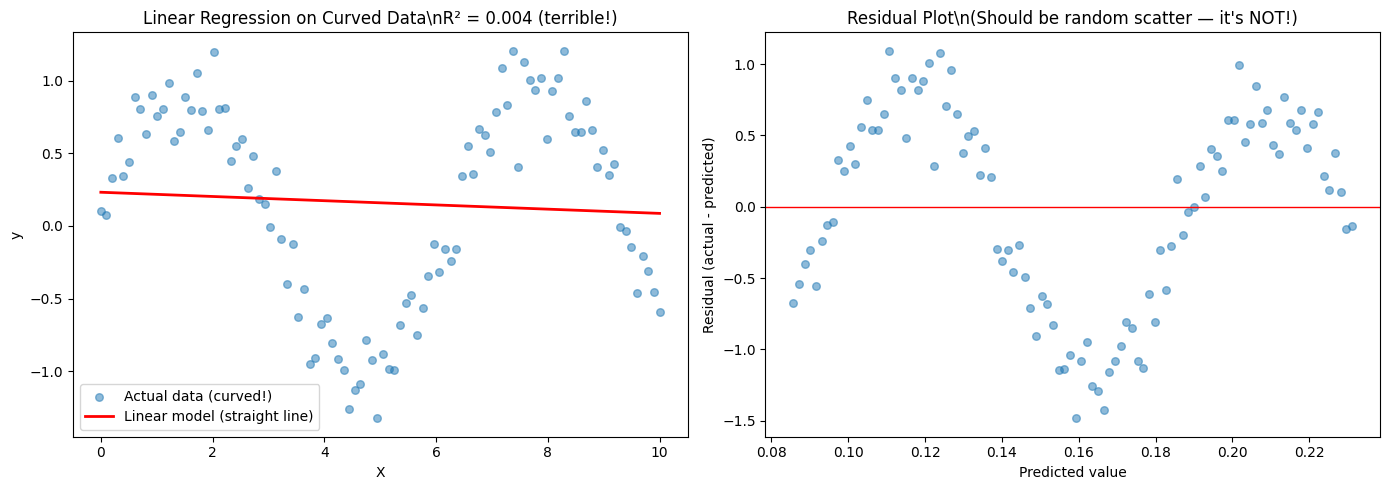

WHAT YOU SEE:
  LEFT:  The straight line CANNOT capture the curved pattern.
  RIGHT: The residuals show a clear WAVE pattern.

HOW TO DIAGNOSE ANY MODEL:
  Random residuals (like scattered dots) = GOOD model
  Patterned residuals (curves, funnels)  = WRONG model type

THIS IS LINEAR REGRESSION'S FUNDAMENTAL LIMITATION:
  It can only draw straight lines.
  The real world is full of curves, interactions, and non-linear patterns.

This is EXACTLY why we need more powerful models:
  → Decision Trees (Step 3): split data with if/then rules
  → Random Forest (Step 4): wisdom of crowds (many trees voting)
  → Neural Networks (Step 5+): can learn ANY pattern


In [10]:
# ============================================================
# WHEN LINEAR REGRESSION FAILS — This is the most important part
# ============================================================
# Linear Regression assumes the relationship is a STRAIGHT LINE.
# But what if the real pattern is a CURVE?
# Let's see it fail spectacularly — and understand WHY.

# Create fake data that follows a CURVED pattern (sine wave + noise)
np.random.seed(42)
X_curve = np.linspace(0, 10, 100).reshape(-1, 1)    # 100 points from 0 to 10
y_curve = np.sin(X_curve).ravel() + np.random.normal(0, 0.2, 100)  # sine wave + noise

# Try to fit a STRAIGHT LINE to this CURVED data
model_bad = LinearRegression()
model_bad.fit(X_curve, y_curve)
y_pred_bad = model_bad.predict(X_curve)
r2_bad = r2_score(y_curve, y_pred_bad)

# Plot it — two charts side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# LEFT CHART: The straight line trying to fit curved data
# You can SEE that the line doesn't follow the pattern at all.
axes[0].scatter(X_curve, y_curve, alpha=0.5, s=30, label='Actual data (curved!)')
axes[0].plot(X_curve, y_pred_bad, color='red', linewidth=2, label='Linear model (straight line)')
axes[0].set_title(f'Linear Regression on Curved Data\\nR² (R-squared) = {r2_bad:.3f} (terrible!)', fontsize=12)
axes[0].set_xlabel('X')
axes[0].set_ylabel('y')
axes[0].legend()

# RIGHT CHART: The RESIDUAL PLOT — this is how you DIAGNOSE the problem
# Residuals = actual - predicted. If the model is good, residuals are RANDOM.
# If there's a pattern in the residuals, the model is MISSING something.
residuals = y_curve - y_pred_bad
axes[1].scatter(y_pred_bad, residuals, alpha=0.5, s=30)
axes[1].axhline(y=0, color='red', linewidth=1)  # perfect model would have all points on this line
axes[1].set_title("Residual Plot\\n(Should be random scatter — it's NOT!)", fontsize=12)
axes[1].set_xlabel('Predicted value')
axes[1].set_ylabel('Residual (actual - predicted)')

plt.tight_layout()
plt.show()

print("WHAT YOU SEE:")
print("  LEFT:  The straight line CANNOT capture the curved pattern.")
print("  RIGHT: The residuals show a clear WAVE pattern.")
print()
print("HOW TO DIAGNOSE ANY MODEL:")
print("  Random residuals (like scattered dots) = GOOD model")
print("  Patterned residuals (curves, funnels)  = WRONG model type")
print()
print("THIS IS LINEAR REGRESSION'S FUNDAMENTAL LIMITATION:")
print("  It can only draw straight lines.")
print("  The real world is full of curves, interactions, and non-linear patterns.")
print()
print("This is EXACTLY why we need more powerful models:")
print("  → Decision Trees (Step 3): split data with if/then rules")
print("  → Random Forest (Step 4): wisdom of crowds (many trees voting)")
print("  → Neural Networks (Step 5+): can learn ANY pattern")

## Part 10: Residual Plot for Our Real Model

Let's check: does our California Housing model have patterned residuals?

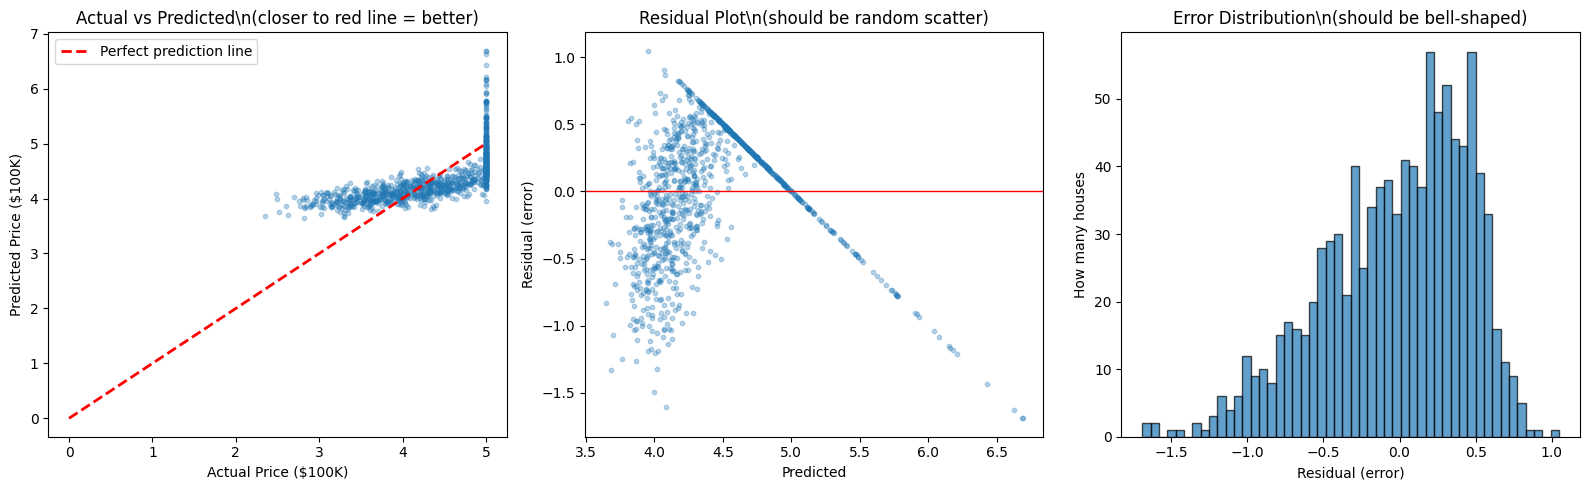

HOW TO READ THESE THREE CHARTS:

1. ACTUAL vs PREDICTED:
   Points near the red line = good predictions
   Points far from it = bad predictions
   Wide scatter = model isn't capturing the pattern well

2. RESIDUAL PLOT:
   Random scatter around 0 = model is doing its best
   Patterns/curves = model is systematically wrong in some areas
   Funnel shape = model is worse for certain value ranges

3. ERROR DISTRIBUTION:
   Bell-shaped and centered at 0 = errors are random (good)
   Skewed = model is biased (consistently over- or under-predicting)

WHAT TO TELL YOUR STUDENTS:
  'Always plot your residuals. They tell you what the R² score hides.'


In [11]:
# ============================================================
# RESIDUAL ANALYSIS ON OUR REAL HOUSING MODEL
# ============================================================
# Let's apply the same diagnostic to our actual housing model.
# Three charts, each tells a different story:

y_pred_real = model_right.predict(X_test_right)
residuals_real = y_test_r - y_pred_real

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# CHART 1: Actual vs Predicted — should cluster around the red diagonal line
# If the model were perfect, every dot would sit ON the red line.
# Dots far from the line = bad predictions.
axes[0].scatter(y_test_r, y_pred_real, alpha=0.3, s=10)
axes[0].plot([0, 5], [0, 5], 'r--', linewidth=2, label='Perfect prediction line')
axes[0].set_xlabel('Actual Price ($100K)')
axes[0].set_ylabel('Predicted Price ($100K)')
axes[0].set_title('Actual vs Predicted\\n(closer to red line = better)')
axes[0].legend()

# CHART 2: Residual Plot — should look like random scatter
# If you see a pattern (curve, funnel, bands), the model is missing something.
axes[1].scatter(y_pred_real, residuals_real, alpha=0.3, s=10)
axes[1].axhline(y=0, color='red', linewidth=1)
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Residual (error)')
axes[1].set_title('Residual Plot\\n(should be random scatter)')

# CHART 3: Distribution of Residuals — should be bell-shaped (normal)
# If it's skewed, the model is systematically biased in one direction.
axes[2].hist(residuals_real, bins=50, edgecolor='black', alpha=0.7)
axes[2].set_xlabel('Residual (error)')
axes[2].set_ylabel('How many houses')
axes[2].set_title('Error Distribution\\n(should be bell-shaped)')

plt.tight_layout()
plt.show()

print("HOW TO READ THESE THREE CHARTS:")
print()
print("1. ACTUAL vs PREDICTED:")
print("   Points near the red line = good predictions")
print("   Points far from it = bad predictions")
print("   Wide scatter = model isn't capturing the pattern well")
print()
print("2. RESIDUAL PLOT:")
print("   Random scatter around 0 = model is doing its best")
print("   Patterns/curves = model is systematically wrong in some areas")
print("   Funnel shape = model is worse for certain value ranges")
print()
print("3. ERROR DISTRIBUTION:")
print("   Bell-shaped and centered at 0 = errors are random (good)")
print("   Skewed = model is biased (consistently over- or under-predicting)")
print()
print("WHAT TO TELL YOUR STUDENTS:")
print("  'Always plot your residuals. They tell you what the R² (R-squared) score hides.'")

## Part 11: Exercises — Poke At It Until You Own It

Don't skip these. This is where passive understanding becomes active knowledge.

### Exercise 1: Predict with a SINGLE feature
Train a model using ONLY `MedInc` (median income). What's the R²?
Now try ONLY `AveRooms`. Which single feature is the best predictor?
Why do you think that is?

In [12]:
# ============================================================
# EXERCISE 1: Which single feature is the best predictor?
# ============================================================
# We'll train a separate model using ONLY one feature at a time.
# This answers: "If you could only know ONE thing about a house,
# what should it be to best predict the price?"
#
# This is useful in real projects — you often want to know which
# features carry the most signal before building complex models.

print(f"All available features: {data.feature_names}")
print()
print(f"{'Feature':>12}  {'R² (R-squared) Score':>10}  Visual                                  Interpretation")
print("-" * 90)

# Loop through each feature, train a model with JUST that one feature
for i, name in enumerate(data.feature_names):
    model_single = LinearRegression()
    # X_train_r[:, i:i+1] = grab just column i from the training data
    model_single.fit(X_train_r[:, i:i+1], y_train_r)
    r2_single = r2_score(y_test_r, model_single.predict(X_test_r[:, i:i+1]))
    
    # Visual bar chart using text characters
    bar = "█" * int(max(0, r2_single) * 40)
    
    # Interpretation of the R² value
    if r2_single > 0.3:
        interp = "← STRONG predictor on its own"
    elif r2_single > 0.05:
        interp = "← Some predictive power"
    elif r2_single > 0:
        interp = "← Weak predictor alone"
    else:
        interp = "← WORSE than guessing the average!"
    
    print(f"{name:>12}: R² = {r2_single:>7.4f}  {bar:40s} {interp}")

print(f"")
print(f"CLASS DISCUSSION QUESTIONS:")
print(f"  1. Why is MedInc (median income) by far the strongest predictor?")
print(f"     Hint: What does neighborhood income tell you about house values?")
print(f"")
print(f"  2. Why does AveBedrms have NEGATIVE R²?")
print(f"     Negative R² means the model is WORSE than just guessing the average!")
print(f"     This happens when a feature has almost no relationship with the target,")
print(f"     and the model's attempt to use it introduces more error than it removes.")
print(f"")
print(f"  3. KEY TAKEAWAY: A single feature (MedInc alone = R² {0.44:.2f}) captures")
print(f"     most of what 8 features together capture (R² {r2_test:.2f}).\"")
print(f"     This is common in real data — a few features do most of the work.")

All available features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']

     Feature    R² Score  Visual                                  Interpretation
------------------------------------------------------------------------------------------
      MedInc: R² =  0.4423  █████████████████                        ← STRONG predictor on its own
    HouseAge: R² =  0.0053                                           ← Weak predictor alone
    AveRooms: R² =  0.0205                                           ← Weak predictor alone
   AveBedrms: R² = -0.0010                                           ← WORSE than guessing the average!
  Population: R² = -0.0004                                           ← WORSE than guessing the average!
    AveOccup: R² =  0.0024                                           ← Weak predictor alone
    Latitude: R² = -0.0007                                           ← WORSE than guessing the average!
   Longitude: R² 

### Exercise 2: What happens with MORE data?

Train on 10%, 25%, 50%, 75%, 100% of the training data.
Does the model get better with more data? At what point does it plateau?

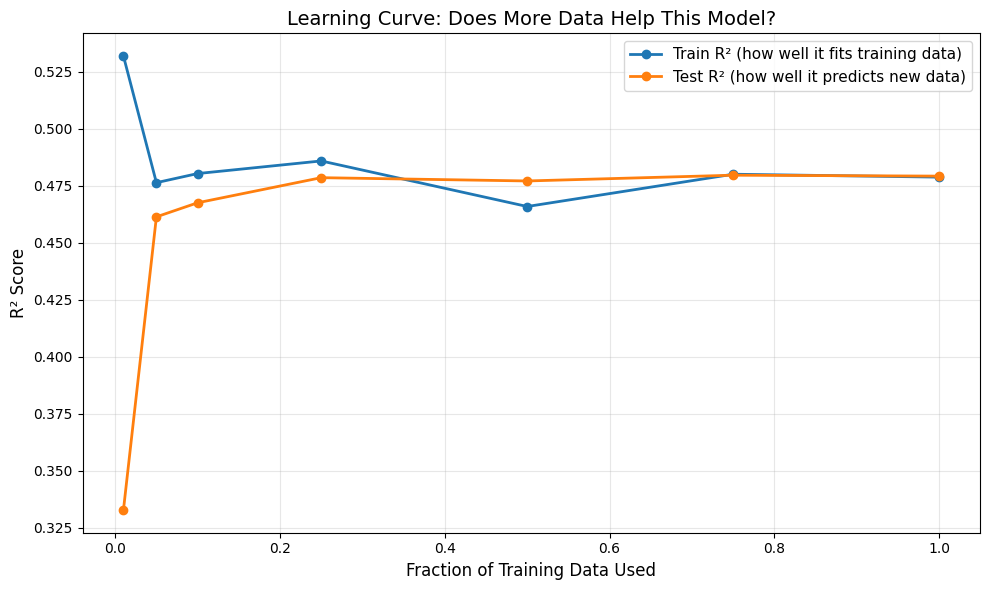

HOW TO READ A LEARNING CURVE:

  1. TRAIN SCORE starts HIGH and DROPS as you add data.
     Why? It's easy to fit a line through 10 points. Hard to fit 5,000.
     More data = harder to memorize = lower train score.

  2. TEST SCORE starts LOW and RISES as you add data.
     Why? More data = model learns better patterns = predicts new data better.

  3. The two lines CONVERGE. When they meet, more data WON'T help.
     At that point, you need a BETTER MODEL, not more data.

THREE SCENARIOS (memorize these!):

  BIG GAP, high train, low test = OVERFITTING
    → Model is too complex. It memorized instead of learning.
    → Fix: simpler model, more data, or regularization

  SMALL GAP, but BOTH scores are low = UNDERFITTING
    → Model is too simple. A straight line can't capture the pattern.
    → Fix: more complex model (Decision Tree, Neural Net)
    → THIS IS WHAT WE SEE HERE. Linear Regression has hit its ceiling.

  SMALL GAP, BOTH scores are high = JUST RIGHT
    → Model generalize

In [13]:
# ============================================================
# EXERCISE 2: LEARNING CURVE — Does more data help?
# ============================================================
# This is one of the most important diagnostic tools in ML (Machine Learning).
# It answers: "Should I collect MORE DATA, or use a BETTER MODEL?"
#
# We'll train the same model with different amounts of data
# and see how train/test scores change.

fractions = [0.01, 0.05, 0.1, 0.25, 0.5, 0.75, 1.0]  # 1% to 100% of training data
train_scores = []
test_scores = []

for frac in fractions:
    n = int(len(X_train_right) * frac)  # how many samples to use
    model_frac = LinearRegression()
    model_frac.fit(X_train_right[:n], y_train_r[:n])  # train on subset
    
    # Score on BOTH the training subset AND the full test set
    train_scores.append(r2_score(y_train_r[:n], model_frac.predict(X_train_right[:n])))
    test_scores.append(r2_score(y_test_r, model_frac.predict(X_test_right)))

plt.figure(figsize=(10, 6))
plt.plot(fractions, train_scores, 'o-', label='Train R² (R-squared) (how well it fits training data)', linewidth=2)
plt.plot(fractions, test_scores, 'o-', label='Test R² (how well it predicts new data)', linewidth=2)
plt.xlabel('Fraction of Training Data Used', fontsize=12)
plt.ylabel('R² Score', fontsize=12)
plt.title('Learning Curve: Does More Data Help This Model?', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("HOW TO READ A LEARNING CURVE:")
print()
print("  1. TRAIN SCORE starts HIGH and DROPS as you add data.")
print("     Why? It's easy to fit a line through 10 points. Hard to fit 5,000.")
print("     More data = harder to memorize = lower train score.")
print()
print("  2. TEST SCORE starts LOW and RISES as you add data.")
print("     Why? More data = model learns better patterns = predicts new data better.")
print()
print("  3. The two lines CONVERGE. When they meet, more data WON'T help.")
print("     At that point, you need a BETTER MODEL, not more data.")
print()
print("THREE SCENARIOS (memorize these!):")
print()
print("  BIG GAP, high train, low test = OVERFITTING")
print("    → Model is too complex. It memorized instead of learning.")
print("    → Fix: simpler model, more data, or regularization")
print()
print("  SMALL GAP, but BOTH scores are low = UNDERFITTING")
print("    → Model is too simple. A straight line can't capture the pattern.")
print("    → Fix: more complex model (Decision Tree, Neural Net)")
print("    → THIS IS WHAT WE SEE HERE. Linear Regression has hit its ceiling.")
print()
print("  SMALL GAP, BOTH scores are high = JUST RIGHT")
print("    → Model generalizes well. Ship it!")

## Part 12: Connecting It All — The Map Forward

Here's what you just learned, and how it connects to everything that follows:

```
What You Learned Here          Where It Shows Up Next
─────────────────────          ──────────────────────
Loss function (MSE)       →    Cross-entropy loss (classification)
                          →    Loss functions in PyTorch (neural nets)

train/test split          →    EVERY model you'll ever build

R², RMSE, MAE             →    Precision, Recall, F1 (classification)
                          →    BLEU (a score for translation quality), ROUGE (a score for summarization quality) (NLP (Natural Language Processing))
                          →    Hit Rate, MRR (Mean Reciprocal Rank — how high the correct answer appears in search results) (RAG (Retrieval-Augmented Generation — connecting AI to your documents) systems)

Feature scaling           →    Required for neural networks
                          →    Data leakage concept in all of ML

Data leakage              →    #1 mistake in production ML

Residual analysis         →    Diagnosing ANY model's failures

Overfitting/underfitting  →    THE central tension in all of ML
                          →    Regularization, dropout (DL (Deep Learning))
                          →    Why Random Forest beats Decision Tree

Learning curves           →    Deciding: more data vs better model?

"LR (Linear Regression) can't capture curves" →    WHY we need Decision Trees (Step 3)
                          →    WHY we need Neural Nets (Step 5+)
```

### You Are Now Ready For Step 2: Logistic Regression

Step 2 takes everything you just learned and applies it to
**classification** (yes/no, survived/died, spam/not-spam).

The key addition: instead of predicting a number, you predict a
**probability** — and that's where confusion matrices, precision,
recall, and F1 scores enter the picture.

But the foundation (loss → optimize → evaluate → diagnose) is
IDENTICAL to what you just did here.

---

## Self-Check: Can You Answer These?

Before moving to Step 2, make sure you can answer each of these
**without looking at the notebook:**

1. What are the 3 steps that ALL ML algorithms share?
2. What does `model.fit()` actually do?
3. Why do we square the errors in MSE instead of just averaging them?
4. What does R² = 0.6 mean in plain English?
5. Why must you split BEFORE scaling? What goes wrong if you don't?
6. What does a patterned residual plot tell you?
7. On a learning curve, what does it mean when train and test scores converge but both are low?
8. When would you choose Linear Regression over a more complex model?

If you can answer all 8, you own this material. Move to Step 2.